# 🌳 The Simpsons — Árbol de Decisión para Regresión
**Variable objetivo:** `imdb_rating`  
**Predictores:** `viewers_millions`, `season`, `duration_min`, `number_in_season`  
**Splits:** 80/20 · 70/30 · 60/40  

---

## 0. Imports y configuración

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from config.database import engine

os.makedirs("../data/graficas", exist_ok=True)
GRAFICAS = "../data/graficas"

plt.rcParams.update({"figure.figsize": (12, 6), "axes.grid": True, "grid.alpha": 0.3})
sns.set_theme(style="whitegrid", palette="muted")
print("✅ Imports OK")

✅ Imports OK


## 1. Carga de datos desde PostgreSQL

In [2]:
df = pd.read_sql("""
    SELECT episode_id, viewers_millions, imdb_rating,
           duration_min, season, number_in_season
    FROM fact_ratings
    ORDER BY episode_id
""", engine)

print(f"Total registros: {len(df)}")
df.head()

Total registros: 768


,episode_id,viewers_millions,imdb_rating,duration_min,season,number_in_season
0,1,0.904716,0.461538,0.0,0.0,0.000000
1,2,0.818415,0.820513,0.0,0.0,0.041667
2,3,0.933269,0.846154,0.0,0.0,0.083333
3,4,0.945460,0.794872,1.0,0.0,0.125000
4,5,0.760026,0.641026,0.0,0.0,0.166667


## 2. Preparación de datos

In [3]:
FEATURES = ["viewers_millions", "season", "duration_min", "number_in_season"]
TARGET   = "imdb_rating"

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Registros para modelado: {len(df_model)}")
print(f"\nEstadísticas de la variable objetivo ({TARGET}):")
print(y.describe().round(3))

Registros para modelado: 768

Estadísticas de la variable objetivo (imdb_rating):
count    768.000
mean       0.484
std        0.153
min        0.000
25%        0.385
50%        0.487
75%        0.590
max        1.000
Name: imdb_rating, dtype: float64


## 3. Función de métricas

In [4]:
def calcular_metricas(y_true, y_pred, nombre_split):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {"Split": nombre_split, "R²": round(r2, 4),
            "RMSE": round(rmse, 4), "MAE": round(mae, 4)}

resultados = []

## 4. Split 1 — 80% entrenamiento / 20% prueba

Split 80/20
  Train: 614 | Test: 154
  R²   = 0.2118
  RMSE = 0.1381
  MAE  = 0.1077


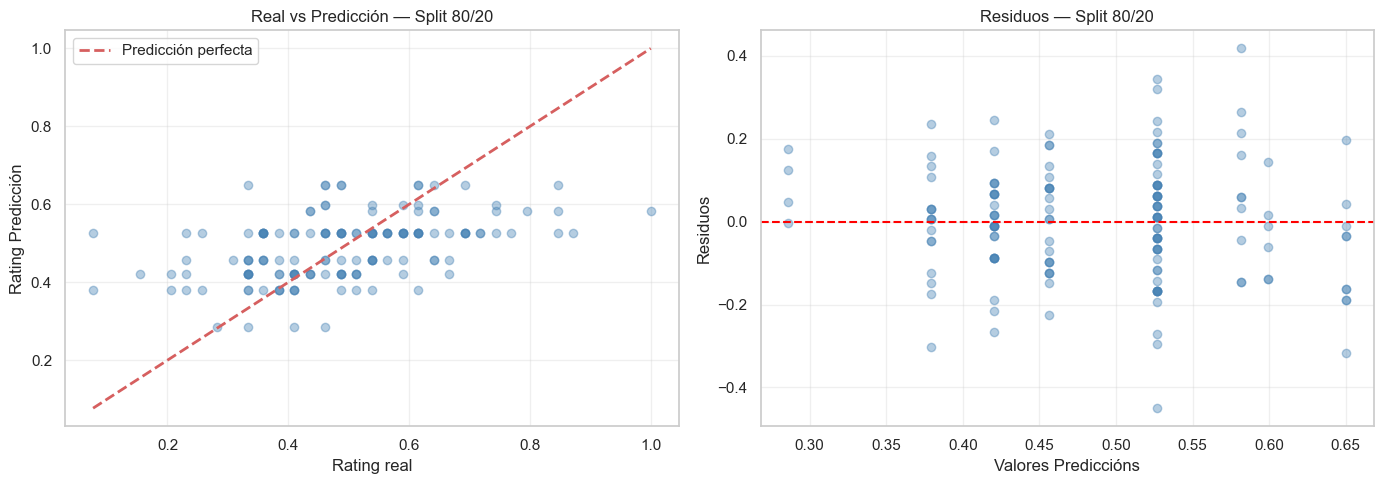

In [5]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.20, random_state=42)

# Árbol con profundidad controlada para evitar sobreajuste
tree1 = DecisionTreeRegressor(max_depth=3, min_samples_leaf=15, min_samples_split=20, random_state=42)
tree1.fit(X_train1, y_train1)
y_pred1 = tree1.predict(X_test1)

m1 = calcular_metricas(y_test1, y_pred1, "80/20")
resultados.append(m1)

print(f"Split 80/20")
print(f"  Train: {len(X_train1)} | Test: {len(X_test1)}")
print(f"  R²   = {m1['R²']}")
print(f"  RMSE = {m1['RMSE']}")
print(f"  MAE  = {m1['MAE']}")

# Gráfica real vs Predicción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test1, y_pred1, alpha=0.4, color='steelblue')
lim = [min(y_test1.min(), y_pred1.min()), max(y_test1.max(), y_pred1.max())]
axes[0].plot(lim, lim, 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Rating real'); axes[0].set_ylabel('Rating Predicción')
axes[0].set_title('Real vs Predicción — Split 80/20'); axes[0].legend()

residuos1 = y_test1 - y_pred1
axes[1].scatter(y_pred1, residuos1, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Valores Prediccións'); axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos — Split 80/20')

plt.tight_layout()
plt.savefig(f"{GRAFICAS}/arbol_reg_split1.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Split 2 — 70% entrenamiento / 30% prueba

Split 70/30
  Train: 537 | Test: 231
  R²   = 0.2195
  RMSE = 0.1391
  MAE  = 0.1095


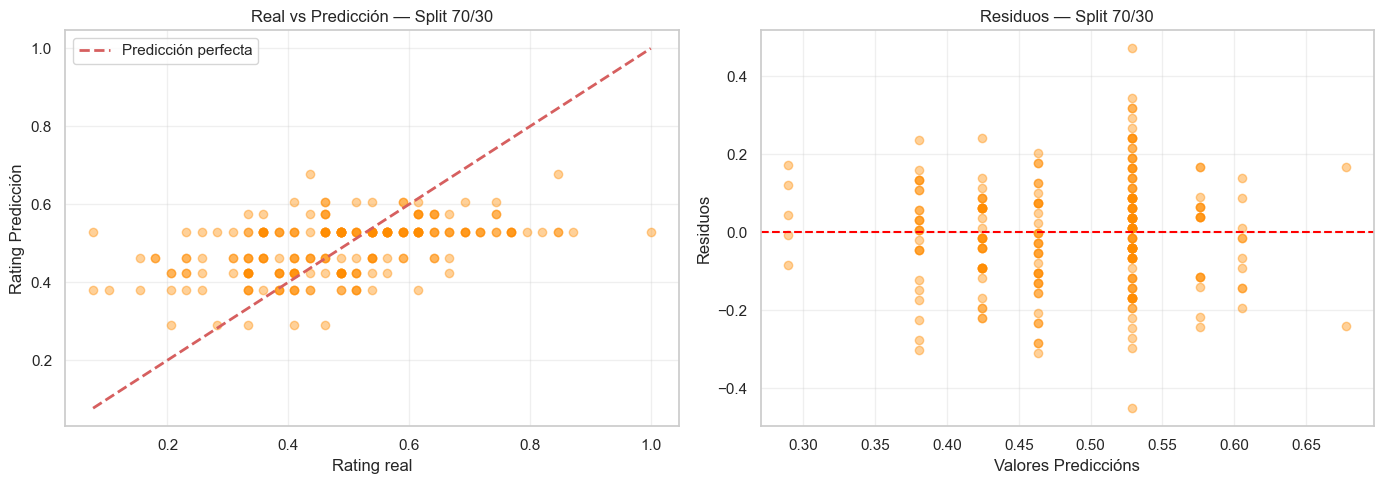

In [6]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.30, random_state=42)

tree2 = DecisionTreeRegressor(max_depth=3, min_samples_leaf=15, min_samples_split=20, random_state=42)
tree2.fit(X_train2, y_train2)
y_pred2 = tree2.predict(X_test2)

m2 = calcular_metricas(y_test2, y_pred2, "70/30")
resultados.append(m2)

print(f"Split 70/30")
print(f"  Train: {len(X_train2)} | Test: {len(X_test2)}")
print(f"  R²   = {m2['R²']}")
print(f"  RMSE = {m2['RMSE']}")
print(f"  MAE  = {m2['MAE']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test2, y_pred2, alpha=0.4, color='darkorange')
lim = [min(y_test2.min(), y_pred2.min()), max(y_test2.max(), y_pred2.max())]
axes[0].plot(lim, lim, 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Rating real'); axes[0].set_ylabel('Rating Predicción')
axes[0].set_title('Real vs Predicción — Split 70/30'); axes[0].legend()

residuos2 = y_test2 - y_pred2
axes[1].scatter(y_pred2, residuos2, alpha=0.4, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Valores Prediccións'); axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos — Split 70/30')

plt.tight_layout()
plt.savefig(f"{GRAFICAS}/arbol_reg_split2.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Split 3 — 60% entrenamiento / 40% prueba

Split 60/40
  Train: 460 | Test: 308
  R²   = 0.1397
  RMSE = 0.1473
  MAE  = 0.1172


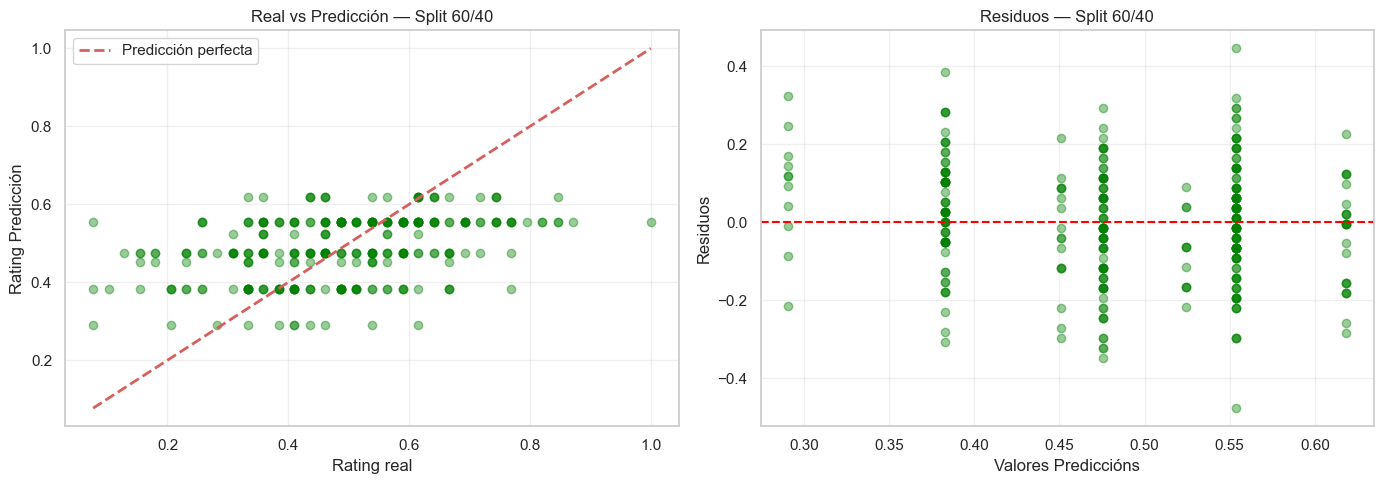

In [7]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.40, random_state=42)

tree3 = DecisionTreeRegressor(max_depth=3, min_samples_leaf=15, min_samples_split=20, random_state=42)
tree3.fit(X_train3, y_train3)
y_pred3 = tree3.predict(X_test3)

m3 = calcular_metricas(y_test3, y_pred3, "60/40")
resultados.append(m3)

print(f"Split 60/40")
print(f"  Train: {len(X_train3)} | Test: {len(X_test3)}")
print(f"  R²   = {m3['R²']}")
print(f"  RMSE = {m3['RMSE']}")
print(f"  MAE  = {m3['MAE']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test3, y_pred3, alpha=0.4, color='green')
lim = [min(y_test3.min(), y_pred3.min()), max(y_test3.max(), y_pred3.max())]
axes[0].plot(lim, lim, 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Rating real'); axes[0].set_ylabel('Rating Predicción')
axes[0].set_title('Real vs Predicción — Split 60/40'); axes[0].legend()

residuos3 = y_test3 - y_pred3
axes[1].scatter(y_pred3, residuos3, alpha=0.4, color='green')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Valores Prediccións'); axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos — Split 60/40')

plt.tight_layout()
plt.savefig(f"{GRAFICAS}/arbol_reg_split3.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualización del árbol (Split 80/20)

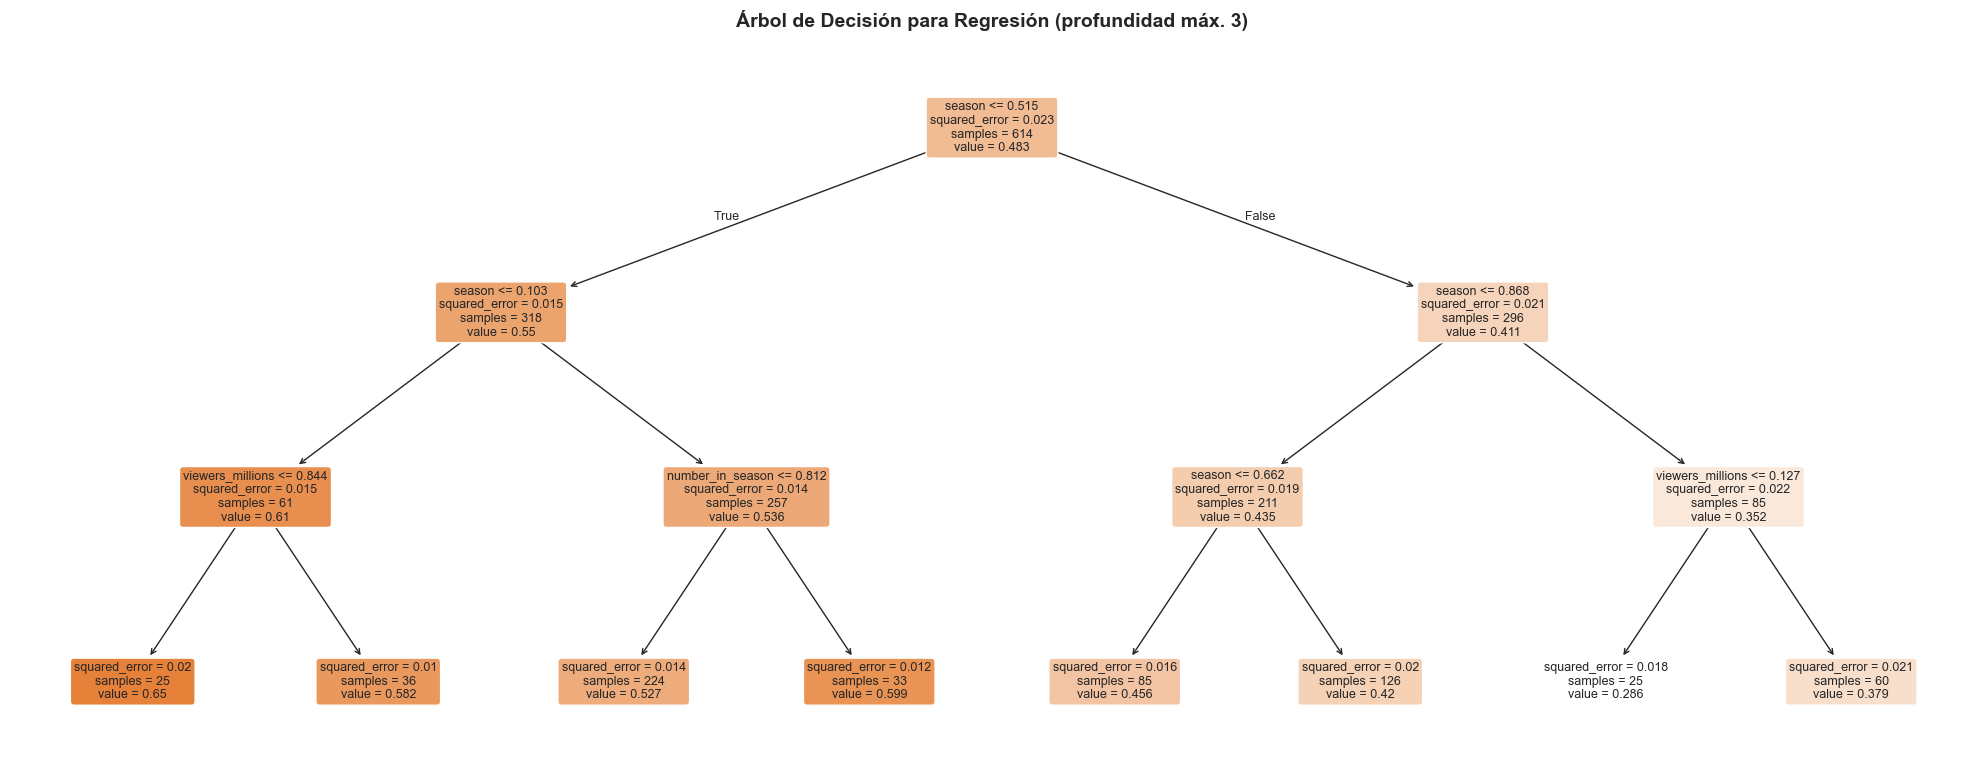


Reglas del árbol (primeros 3 niveles):
|--- season <= 0.51
|   |--- season <= 0.10
|   |   |--- viewers_millions <= 0.84
|   |   |   |--- value: [0.65]
|   |   |--- viewers_millions >  0.84
|   |   |   |--- value: [0.58]
|   |--- season >  0.10
|   |   |--- number_in_season <= 0.81
|   |   |   |--- value: [0.53]
|   |   |--- number_in_season >  0.81
|   |   |   |--- value: [0.60]
|--- season >  0.51
|   |--- season <= 0.87
|   |   |--- season <= 0.66
|   |   |   |--- value: [0.46]
|   |   |--- season >  0.66
|   |   |   |--- value: [0.42]
|   |--- season >  0.87
|   |   |--- viewers_millions <= 0.13
|   |   |   |--- value: [0.29]
|   |   |--- viewers_millions >  0.13
|   |   |   |--- value: [0.38]



In [8]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree1, feature_names=FEATURES, filled=True,
          rounded=True, max_depth=3, ax=ax, fontsize=9)
plt.title("Árbol de Decisión para Regresión (profundidad máx. 3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/arbol_reg_visualizacion.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nReglas del árbol (primeros 3 niveles):")
print(export_text(tree1, feature_names=FEATURES, max_depth=3))

## 8. Importancia de variables

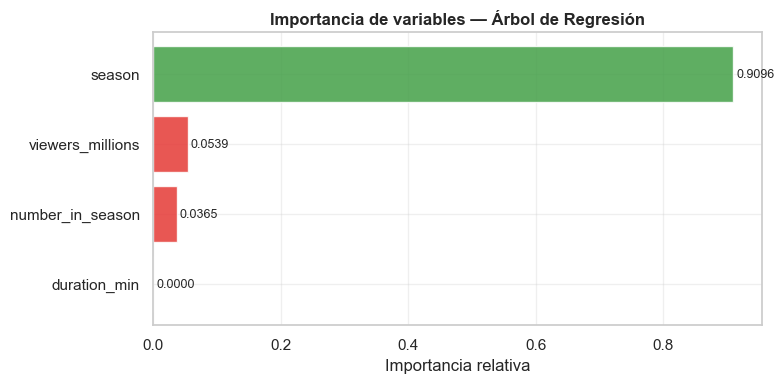

In [9]:
importancias = pd.DataFrame({
    "Variable": FEATURES,
    "Importancia": tree1.feature_importances_
}).sort_values("Importancia", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E53935' if v < 0.1 else ('#FF9800' if v < 0.3 else '#43A047')
          for v in importancias["Importancia"]]
ax.barh(importancias["Variable"], importancias["Importancia"],
        color=colors, alpha=0.85)
ax.set_xlabel("Importancia relativa")
ax.set_title("Importancia de variables — Árbol de Regresión", fontweight='bold')
for i, v in enumerate(importancias["Importancia"]):
    ax.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/arbol_reg_importancia.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary — Tabla comparativa de los 3 splits


  SUMMARY — ÁRBOL DE DECISIÓN PARA REGRESIÓN
Split     R²   RMSE    MAE
80/20 0.2118 0.1381 0.1077
70/30 0.2195 0.1391 0.1095
60/40 0.1397 0.1473 0.1172

Mejor R² obtenido : 0.2195 (Split 70/30)
Menor RMSE        : 0.1381 (Split 80/20)
Menor MAE         : 0.1077 (Split 80/20)


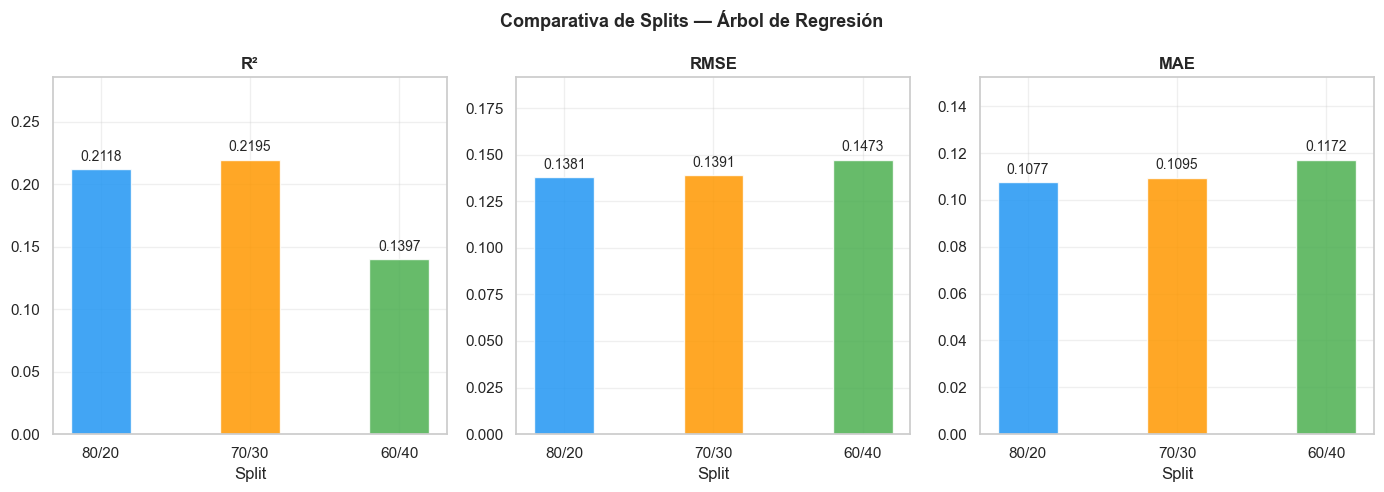

,Split,R²,RMSE,MAE
0,80/20,0.2118,0.1381,0.1077
1,70/30,0.2195,0.1391,0.1095
2,60/40,0.1397,0.1473,0.1172


In [12]:
df_res = pd.DataFrame(resultados)

print("\n" + "="*55)
print("  SUMMARY — ÁRBOL DE DECISIÓN PARA REGRESIÓN")
print("="*55)
print(df_res.to_string(index=False))
print("="*55)
print(f"\nMejor R² obtenido : {df_res['R²'].max()} (Split {df_res.loc[df_res['R²'].idxmax(), 'Split']})")
print(f"Menor RMSE        : {df_res['RMSE'].min()} (Split {df_res.loc[df_res['RMSE'].idxmin(), 'Split']})")
print(f"Menor MAE         : {df_res['MAE'].min()} (Split {df_res.loc[df_res['MAE'].idxmin(), 'Split']})")

# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores = ['#2196F3', '#FF9800', '#4CAF50']
for ax, met in zip(axes, ["R²", "RMSE", "MAE"]):
    bars = ax.bar(df_res["Split"], df_res[met], color=colores, alpha=0.85, width=0.4)
    ax.set_title(met, fontweight='bold')
    ax.set_xlabel("Split")
    ax.set_ylim(0, df_res[met].max() * 1.3)
    for bar, val in zip(bars, df_res[met]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + df_res[met].max()*0.03,
                f"{val:.4f}", ha='center', fontsize=10)

plt.suptitle("Comparativa de Splits — Árbol de Regresión", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/arbol_reg_summary.png", dpi=150, bbox_inches='tight')
plt.show()

df_res